# <center> Сегментация клиентов онлайн магазина подарков

## Постановка задачи


<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Маркетинг — неотъемлемая часть любого бизнеса. Для повышения прибыли компании важно понимать своего клиента, его пожелания и предпочтения. С появлением электронной коммерции, или онлайн-продаж, стало намного проще собирать данные о клиентах, анализировать их, находить закономерности и реализовывать маркетинговые кампании.

Большинство интернет-магазинов используют инструменты веб-аналитики, чтобы отслеживать просмотры страниц, количество и поведение посетителей и коэффициент отказов. Но отчёта из Google Analytics или аналогичной системы может быть недостаточно для полного понимания того, как клиенты взаимодействуют с сайтом. Компаниям важно иметь возможность быстро и точно реагировать на перемены в поведении клиентов, создавая инструменты, которые обнаруживают эти изменения практически в режиме реального времени.

Машинное обучение помогает поисковой системе анализировать огромное количество данных о посетителях платформы, узнавать модели поведения профессиональных покупателей, определять категорию клиентов (например, лояльные/перспективные/новички/спящие/ушедшие) и выбирать правильную стратегию взаимодействия с ними.

Стоит также отметить, что компании, использующие машинное обучение на своих платформах электронной коммерции, могут постоянно повышать эффективность бизнес-процессов: настраивать товарную выборку персонально для каждого покупателя и предлагать выгодную цену в соответствии с бюджетом клиента и т. д. Эта задача относится к категории построения рекомендательных систем, речь о которых пойдёт в следующем разделе нашего курса.

> Как правило, наборы данных для электронной коммерции являются частной собственностью и, следовательно, их трудно найти среди общедоступных данных. Однако [The UCI Machine Learning Repository](http://archive.ics.uci.edu/ml/index.php)  создал набор данных, содержащий фактические транзакции за 2010 и 2011 годы. С ним нам как раз и предлагается поработать в этом кейсе. 

> В нашем распоряжении будет набор данных, который содержит все транзакции, произошедшие в период с 01/12/2010 по 09/12/2011 для базирующейся в Великобритании компании, занимающейся онлайн-розничной торговлей. Компания в основном продает уникальные подарки на все случаи жизни. Многие клиенты компании являются оптовиками.


**Бизнес-задача:** произвести сегментацию существующих клиентов, проинтерпретировать эти сегменты и определить стратегию взаимодействия с ними.

**Техническая задача для вас как для специалиста в Data Science:** построить модель кластеризации клиентов на основе их покупательской способности, частоты заказов и срока давности последней покупки, определить профиль каждого из кластеров.

**Основные цели проекта:**
1. Произвести предобработку исходного набора данных о транзакциях.
2. Провести разведывательный анализ данных и выявить основные закономерности.
3. Сформировать набор данных о характеристиках каждого из уникальных клиентов.
4. Построить несколько моделей машинного обучения, решающих задачу кластеризации клиентов, определить количество кластеров и проинтерпретировать их.
5. Спроектировать процесс предсказания категории интересов клиента и протестировать вашу модель на новых клиентах.




## Данные и их описание

Данные представляют собой таблицу в формате CSV, в каждой строке которой содержится информация об уникальной транзакции.

Признаки, описывающие каждую транзакцию:

* InvoiceNo — номер счёта-фактуры (уникальный номинальный шестизначный номер, присваиваемый каждой транзакции; буква "C" в начале кода указывает на отмену транзакции);
* StockCode — код товара (уникальное пятизначное целое число, присваиваемое каждому отдельному товару);
* Description — название товара;
* Quantity — количество каждого товара за транзакцию;
* InvoiceDate — дата и время выставления счёта/проведения транзакции;
* UnitPrice — цена за единицу товара в фунтах стерлингов;
* CustomerID — идентификатор клиента (уникальный пятизначный номер, однозначно присваиваемый каждому клиенту);
* Country — название страны, в которой проживает клиент.



Импорт базовых библиотек:

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["patch.force_edgecolor"] = True

import seaborn as sns
from sklearn import decomposition
from sklearn.manifold import TSNE
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.metrics import silhouette_score
from sklearn import cluster
from sklearn import preprocessing
from sklearn import model_selection
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn import linear_model


## 1. Знакомство со структурой данных

Первым делом необходимо понять, с какими данными предстоит работать, и произвести базовую предобработку данных — перевести признаки в необходимые для дальнейшей работы форматы.

Познакомьтесь с исходными данными поближе:

* Проведите статистический анализ исходных данных, посмотрев на основные диапазоны исходных признаков.
* Узнайте, сколько уникальных клиентов совершали транзакции в указанный период.
* Узнайте, из каких стран совершались транзакции.
* Исследуйте данные на наличие пропусков и дубликатов.
* Переведите столбцы в корректные форматы (например, даты в формат datetime).

In [2]:
data = pd.read_csv(
    "./data/data.csv", 
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceID': str} # зачем здесь  -- 'InvoiceID': str, -- непонятно, такого столбца в данных нет
)
print('Data shape: {}'.format(data.shape))
data.head(5)

Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [3]:
# переводим столбец с датами в datetime, определяем период наблюдений
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
print('Date interval {} to {}'.format(data['InvoiceDate'].dt.date.min(), data['InvoiceDate'].dt.date.max()))

Date interval 2010-12-01 to 2011-12-09


In [4]:
# смотрим на количество непустых значений в строках и типы данных в столбцах
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# смотрим на основные диапазоны исходных числовых признаков
data.describe()

,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


In [6]:
# смотрим на основные диапазоны исходных категориальных признаков
data.describe(include=object)

,InvoiceNo,StockCode,Description,CustomerID,Country
count,541909,541909,540455,406829,541909
unique,25900,4070,4223,4372,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17841,United Kingdom
freq,1114,2313,2369,7983,495478


In [7]:
# смотрим, из каких стран делались трансзакции
data['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

## 2. Преобразование, очистка и анализ данных

### 2.1. Преобразование и очистка данных о транзакциях

#### 2.1.1 Пропуски

Пропуски в столбце с идентификатором клиента (CustomerID) и описанием товара свидетельствуют о некорректных/незавершённых транзакциях. Удалите их из данных.

**Примечание.** Если посмотреть на распределение пропусков в столбцах Description и CustomerID, то можно заметить, что достаточно удалить строки, содержащие пропуски в столбце CustomerID, тогда пропуски в столбце Description удаляются автоматически.


In [8]:
# удаляем пропуски в данных
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB


#### 2.1.2. Дубликаты

Проверьте данные на наличие дубликатов. Удалите их из данных.


In [9]:
# удаляем дубликаты
data.drop_duplicates(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  object        
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.6+ MB


#### 2.1.3. Транзакции с отрицательным количеством товара

Из приведённых выше инсайтов о данных мы узнали все особенности отмены заказов. Когда мы будем сегментировать клиентов, мы будем определять их покупательскую способность. При расчёте покупательской способности нам будет очень важно учесть возвраты этого клиента.

Чтобы подсчитать количество возвратов, для начала нам надо определить, сколько уникальных товаров указано в транзакции (корзине) для каждой уникальной пары «клиент — заказ»:


In [10]:
temp = data.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24


**Примечание.** Более 16 % уникальных заказов являются возвратами. Интересный факт: если мы подсчитали количество транзакций, содержащих признак возврата, в изначальной таблице, где на каждый уникальный товар заведена отдельная строка, то мы получили бы, что количество возвратов менее 1 %. Однако это число было бы некорректным.

Создайте в ваших данных о транзакциях признак `QuantityCanceled`. Этот признак будет указывать на количество отменённого впоследствии товара для каждой транзакции, на которую найдётся противоположная ей транзакция с возвратом. Для транзакций, для которых не было возвратов, признак будет равен 0. Для транзакций, для которых указано отрицательное количество товара, но в данных отсутствует контрагент, признак будет пустым.

В качестве вспомогательного инструмента мы подготовили для вас функцию `get_quantity_canceled()`. Эта функция принимает на вход таблицу с транзакциями и возвращает объект `Series` — столбец, в котором указано количество отменённого впоследствии товара для каждой транзакции. Если транзакция не имеет контрагента, этот признак помечается как `NaN`.

Отметим, что эта функция не учитывает сложный случай, когда количество отменённого товара в транзакции-возврате больше, чем количество товара, которое указано в любой из отдельных транзакций на покупку (это случай, когда клиент сделал несколько заказов одного и того же товара, а потом оформил возврат на все товары разом). При желании вы можете самостоятельно модифицировать функцию для предобработки, чтобы учесть этот пограничный случай.

*Осторожно! Поиск отменённых транзакций занимает много времени из-за большого количества строк в таблице. Выполнение следующего кода может занять до 20 минут в зависимости от мощности компьютера.*

In [11]:
def get_quantity_canceled(data):
    """Функция для создания признака количества отменённых заказов. 
    Функция принимает на вход таблицу и возвращает столбец, в котором указано количество отменённого впоследствии товара для кажой транзакции.
    Если транзакция с отрицательным количеством товара не имеет контрагента, данный признак помечается как NaN.

    Args:
        data (DataFrame): таблица с транзакциями

    Returns:
        Series: столбец с количеством отменённого товара
    """
    # Инициализируем нулями Series той же длины, что и столбцы таблицы.
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for index, col in negative_quantity.iterrows():
        # Создаём DataFrame из всех контрагентов
        df_test = data[(data['CustomerID'] == col['CustomerID']) &
                       (data['StockCode']  == col['StockCode']) & 
                       (data['InvoiceDate'] < col['InvoiceDate']) & 
                       (data['Quantity'] > 0)].copy()
        # Транзация-возврат не имеет контрагента — ничего не делаем
        if (df_test.shape[0] == 0): 
            # Помечаем столбец как пропуск
            quantity_canceled.loc[index] = np.nan
        # Транзакция-возврат имеет ровно одного контрагента
        # Добавляем количество отменённого товара в столбец QuantityCanceled 
        elif (df_test.shape[0] == 1): 
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = -col['Quantity']       
        # Транзакция-возврат имеет несколько контрагентов
        # Задаём количество отменённого товара в столбец QuantityCanceled для той транзакции на покупку,
        # в которой количество товара больше количества товаров в транзакции-возврате.
        elif (df_test.shape[0] > 1): 
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)        
            for ind, val in df_test.iterrows():
                if val['Quantity'] < -col['Quantity']: 
                    continue
                quantity_canceled.loc[ind] = -col['Quantity']
                break    
    return quantity_canceled

data['QuantityCanceled'] = get_quantity_canceled(data)

*Осторожно! Поиск отмененных транзакций занимает достаточно длительное время из-за количества строк в таблице. Выполнение следующего кода может занять до 20 минут в зависимости от компьютера.*

Узнайте, сколько транзакций в данных не имеют контрагентов, и, если их количество невелико, удалите их из данных.

Когда вы разобрались с возвратами, удалите транзакции с отрицательным количеством товара — они нам больше не нужны.



In [12]:
# количество трансзакций в данных, не имеющих контрагентов
data['QuantityCanceled'].isnull().sum()

1303

In [13]:
# удаляем строки с этими трансзакциями
data.dropna(inplace=True)
data.shape

(400301, 9)

In [14]:
# оставляем транзакции с неотрицательным количеством товара
data = data[data['Quantity'] > 0]
data.shape

(392732, 9)

#### 2.1.4. Специализированные транзакции

Следующая задача — обработать специальные виды транзакций, которые обозначаются латинскими буквами.

В данных присутствует шесть специальных видов транзакций. С помощью регулярных выражений найдите такие коды товаров (StockCode), которые начинаются с латинских букв (при этом коды могут содержать цифры).

**Подсказка.** В качестве шаблона для поиска используйте строку '^[a-zA-Z]+'.

Чтобы понять, что означают эти коды, можно заглянуть в столбец с описанием (Description), например POST означает почтовые расходы, C2 — расходы на транспортировку, BANK CHARGES — банковские расходы.

Специальные операции не характеризуют покупательскую способность клиентов, так как не относятся напрямую к их покупкам, поэтому такие записи нам не нужны. Удалите все специальные транзакции из таблицы.

In [15]:
# удаляем все специальные транзакции
data = data[~data['StockCode'].str.contains(r'^[a-zA-Z]+', regex=True)]
data.shape

(391183, 9)

#### 2.1.5. Транзакции с товарами без стоимости

При просмотре описательных статистик можно заметить, что на некоторые товары установлена цена в 0 фунтов стерлингов. Таких транзакций оказывается менее 1 % — можно удалить их.

In [16]:
# удаляем записи с товарами по цене 0
data = data[data['UnitPrice'] != 0]
data.shape

(391150, 9)

#### 2.1.6. Общая стоимость товаров в транзакции

Добавьте в ваш датасет общую цену заказа (TotalPrice). Она рассчитывается как:
 
 **общая цена = цена за единицу товара * (количество товаров в заказе - количество возвращённых товаров).**

Этот признак впоследствии поможет вам рассчитать покупательскую способность каждого из клиентов.

In [17]:
# добавляем столбец TotalPrice
data['TotalPrice'] = data['UnitPrice'] * (data['Quantity'] - data['QuantityCanceled'])
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0.0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0.0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34


In [ ]:
#data.to_csv("data/data_cleared.csv", index=False)


In [ ]:
#data2 = pd.read_csv("data/data_cleared.csv")
#data2['InvoiceDate'] = pd.to_datetime(data2['InvoiceDate'])
#data2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0.0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0.0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34


Помимо рекомендованных преобразований, вы также можете придумать собственные и применить их к исходным данным.
После завершения предобработки сохраните результат очищения данных в отдельный файл, чтобы впоследствии вам не приходилось повторять эти действия.


### 2.2. Разведывательный анализ

После предобработки исходных данных произведите разведывательный анализ и исследуйте транзакции, ответив на следующие вопросы:

* Клиенты из каких стран покупают больше и чаще?
* Какие страны приносят наибольшую сезонную выручку?
* Присутствует ли в продажах сезонность (когда покупают чаще)?
* Сгруппируйте данные по датам и часам совершения транзакции и найдите количество заказов на каждый день-час. Затем найдите среднее количество ежедневно поступающих заказов в каждый из часов.
* Каково распределение среднего количества ежедневно поступающих заказов по времени суток (часу совершения транзакции)? 

**Примечание.** Вы можете сформулировать и другие вопросы. Главная цель — извлечь максимум понятной информации из исходных данных.

Свои рассуждения сопроводите графиками и диаграммами.



In [18]:
# смотрим выручку по странам
country_sum = data.groupby(by=['Country'], as_index=False)['TotalPrice'].sum().sort_values(by='TotalPrice', ascending=False)
country_sum.head(8)

,Country,TotalPrice
35,United Kingdom,6797691.44
23,Netherlands,283443.54
10,EIRE,247074.57
14,Germany,201520.71
13,France,181529.63
0,Australia,136950.25
32,Switzerland,51863.75
30,Spain,51764.90


In [19]:
# визуализируем выручку по сранам
country_sum.loc[country_sum['TotalPrice'] < 50000, 'Country'] = 'Other countries' 
fig = px.pie(country_sum, values='TotalPrice', names='Country', title='Выручка по странам', height=400, width=700)
fig.show()

In [20]:
# смотрим национальность покупателей
client_nationality = data.groupby('Country')['CustomerID'].agg(['nunique']).sort_values(by='nunique', ascending=False)
client_nationality.head(8)

,nunique
Country,
United Kingdom,3916
Germany,94
France,87
Spain,30
Belgium,25
Switzerland,21
Portugal,19
Italy,14


In [21]:
# смотрим, сколько всего уникальных покупателей
data['CustomerID'].nunique()

4334

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391150 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         391150 non-null  object        
 1   StockCode         391150 non-null  object        
 2   Description       391150 non-null  object        
 3   Quantity          391150 non-null  int64         
 4   InvoiceDate       391150 non-null  datetime64[ns]
 5   UnitPrice         391150 non-null  float64       
 6   CustomerID        391150 non-null  object        
 7   Country           391150 non-null  object        
 8   QuantityCanceled  391150 non-null  float64       
 9   TotalPrice        391150 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 32.8+ MB


In [23]:
# добавляем колонки с датой, временем и месяцем покупки
data['InvoiceDay'] = data['InvoiceDate'].dt.date
data['InvoiceHour'] = data['InvoiceDate'].dt.hour
data['InvoiceMonth'] = data['InvoiceDate'].dt.month
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled,TotalPrice,InvoiceDay,InvoiceHour,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0.0,15.30,2010-12-01,8,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34,2010-12-01,8,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0.0,22.00,2010-12-01,8,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34,2010-12-01,8,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0.0,20.34,2010-12-01,8,12


Text(0.5, 1.0, 'Количество покупок в зависимости от времени суток')

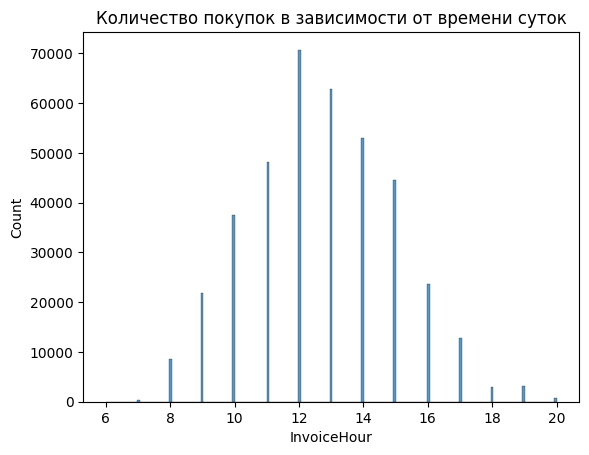

In [ ]:
# визуализируем количество покупок в зависимости от времени суток
sns.histplot(data=data, x="InvoiceHour")
plt.title("Количество покупок в зависимости от времени суток")

Text(0.5, 1.0, 'Сумма покупок в зависимости от времени суток')

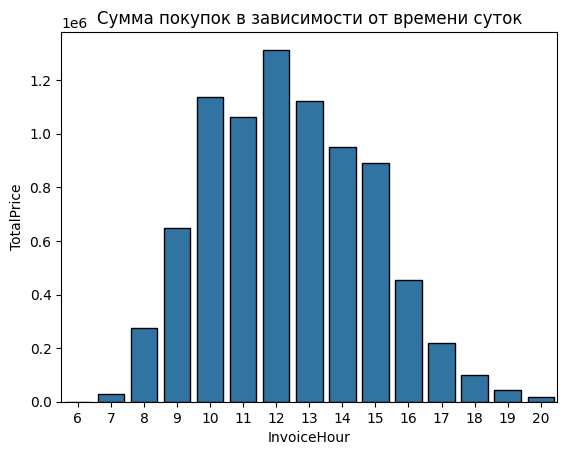

In [32]:
# смотрим сумму покупок в зависимости от времени суток
hour_sum = data.groupby(by=['InvoiceHour'], as_index=False)['TotalPrice'].sum().sort_values(by='TotalPrice', ascending=False)
sns.barplot(data=hour_sum, x= "InvoiceHour", y = "TotalPrice")
plt.title("Сумма покупок в зависимости от времени суток")

### 2.3. Построение RFM-таблицы и поиск RFM-выбросов

Мы добрались до самой интересной части нашей задачи. Нам предстоит сформировать признаки, на основе которых мы будем производить сегментацию клиентов.

Для этого давайте познакомимся с очень популярным методом для анализа потребительской ценности под названием RFM. 

<center> <img src=https://miro.medium.com/max/1400/1*uYQjy9SUjW7iWHc2gGanQQ.png align="right" width="400"/> </center>

Метод заключается в группировке клиентов на основе следующих параметров:
* Recency (Давность) — давность последней покупки клиента;
* Frequency (Частота) — общее количество покупок клиента;
* Monetary Value (Денежная ценность) — сколько денег потратил клиент.


Суть RFM-анализа состоит в том, что мы разделяем всех клиентов на группы в зависимости от того, как давно они сделали последнюю покупку, как часто покупали и насколько большой была сумма их заказов. 

Например, вот так может выглядеть интерпретация кластеров для случая RF-сегментации (анализа на основе давности и частоты заказов клиента):

<img src=https://retailrocket.ru/wp-content/uploads/2017/06/rfm-1.png>

Задача маркетологов — вести клиента в зону лояльных.

Мы можем рассчитать RFM-характеристики для каждого из клиентов в нашем датасете и на их основе с помощью методов кластеризации построить подобные сегменты клиентов, привязанные к нашим данным.

Чтобы получить RFM-таблицу, нам необходимо сгруппировать данные по идентификаторам клиента и рассчитать следующие  агрегированные характеристики:

* Recency для i-го клиента рассчитывается как разница между датой и временем последнего заказа и точкой отсчёта, переведённая в дни:
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    где $t_{ij}$ — дата и время совершения i-ым клиентом своей j-ой покупки.

    В качестве точки отсчёта $t_0$ берём дату на один день «старше», чем все наши данные. Это будет 10 декабря 2011 года (в формате datetime — '2011-12-10 00:00:00').

* Frequency рассчитывается как общее количество уникальных заказов, которые совершил i-ый клиент.
* Monetary Value рассчитывается как общая сумма денег, которую i-ый клиент потратил на наши товары (с учётом возвратов).

Когда вы рассчитаете все характеристики, не забудьте дать столбцам результирующей таблицы соответствующие названия.

In [33]:
now = pd.to_datetime('2011-12-10 00:00:00')
(now - data['InvoiceDate'][0]).days

373

In [34]:
rfm_table= data.groupby('CustomerID').agg({'InvoiceDate': lambda x: (now - x.max()).days,
                                            'InvoiceNo': lambda x: len(x.unique()),
                                            'TotalPrice': 'sum'})
rfm_table.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'}, inplace=True)
rfm_table.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,0.00
12347,2,7,4310.00
12348,75,4,1437.24
12349,18,1,1457.55
12350,310,1,294.40


После того как вы подготовите RFM-таблицу, визуализируйте каждую из трёх компонент, например, в виде коробчатых диаграмм (boxplot). Вы получите примерно следующие результаты (графики могут отличаться в зависимости от того, как вы выполните предобработку данных):

In [ ]:
# вызуализируем распределения, проверяем выбросы
boxes = [px.box(rfm_table, x=column) for column in rfm_table.columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        "Recency","Frequency", "Monetary"
    )
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)

fig.show()

Что интересного здесь можно увидеть? Есть клиенты с аномально большим количеством сделанных заказов (более 100 штук), а также клиенты, общая стоимость заказов которых превышает 190 тысяч фунтов стерлингов.

Чем это плохо? Выбросы могут отрицательно сказаться на результатах работы методов кластеризации, неустойчивых к ним, например алгоритма KMeans, поэтому хотелось бы от них избавиться. Однако терять много ценных данных о клиентах тоже не хочется, поэтому ограничимся верхней границей соответствующей квантили уровня 0.95. Таким образом, мы удалим данные тех клиентов, для которых значение параметра Frequency или параметра Monetary выше, чем у 95 % клиентов.


In [ ]:
# смотим выбросы по стат. данным
rfm_table.describe()

,Recency,Frequency,Monetary
count,4334.000000,4334.000000,4334.000000
mean,92.226581,4.245962,1906.689661
std,100.175327,7.634989,8304.237509
min,0.000000,1.000000,0.000000
25%,17.000000,1.000000,298.257500
50%,50.000000,2.000000,651.395000
75%,142.000000,5.000000,1606.405000
max,373.000000,206.000000,278742.020000


In [40]:
#определяем границы выбросов и удаляем выбросы
qwart95_monet = rfm_table['Monetary'].quantile(0.95)
qwart95_freq = rfm_table['Frequency'].quantile(0.95)

rfm_table_cleared = rfm_table[(rfm_table['Frequency'] <= qwart95_freq) & (rfm_table['Monetary'] <= qwart95_monet)]
rfm_table_cleared.shape

(4044, 3)

In [41]:
# снова смотим стат. данные после удаления выбросов, проверяем результат
rfm_table_cleared.describe()

,Recency,Frequency,Monetary
count,4044.000000,4044.000000,4044.000000
mean,97.485410,3.009891,975.766353
std,101.181582,2.539113,1024.132658
min,0.000000,1.000000,0.000000
25%,21.000000,1.000000,281.290000
50%,56.000000,2.000000,594.100000
75%,155.000000,4.000000,1304.775000
max,373.000000,13.000000,5657.850000


In [42]:
# снова вызуализируем распределения, проверяем результат удаления выбросов
boxes = [px.box(rfm_table_cleared, x=column) for column in rfm_table_cleared.columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        "Recency","Frequency", "Monetary"
    )
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
#fig.write_html('plotly/boxplot_1.html')
fig.show()

In [ ]:
#rfm_table_cleared.to_csv("data/rfm_table_cleared.csv", index=True)

## 3. Моделирование и оценка качества моделей

### 3.1. Кластеризация на основе RFM-характеристик

In [ ]:
#rfm_table_cleared = pd.read_csv("data/rfm_table_cleared.csv", index_col='CustomerID')

#rfm_table_cleared.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,0.00
12347,2,7,4310.00
12348,75,4,1437.24
12349,18,1,1457.55
12350,310,1,294.40


Построим 3D график RFM-характеристик без кластеризации.

In [44]:
fig = px.scatter_3d(
    data_frame=rfm_table_cleared, #DataFrame
    x = 'Recency', #ось абсцисс
    y = 'Frequency', #ось ординат
    z = 'Monetary', #ось аппликат
    opacity=0.7,
    width=1000,
    height=700,
    title='RFM-характеристики без кластеризации'
)
fig.show()

Построим 2D график RFM-характеристик без кластеризации.

Text(0.5, 1.0, '2D график RFM-характеристик без кластеризации')

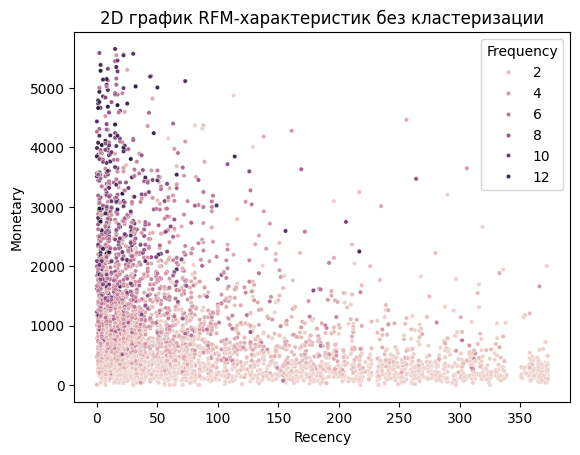

In [45]:
sns.scatterplot(data=rfm_table_cleared, x = "Recency", y = "Monetary", hue = 'Frequency', s=10)
plt.title("2D график RFM-характеристик без кластеризации")

Чтобы результаты кластеризации было удобнее интерпретировать, вы можете уменьшить размерность исходных признаков до двух компонент.

**Подсказка.** Чтобы методы понижения размерности работали стабильно, данные необходимо стандартизировать/нормализовать. Для удобства оберните эти шаги по предобработке данных в pipeline.

Произведите предобработку исходных данных. На основе RFM-признаков кластеризуйте клиентов онлайн-магазина подарков с помощью известных вам методов (используйте минимум три метода).

Подберите оптимальное количество кластеров для выбранных методов с помощью коэффициента силуэта, перебирая возможные значения от 3 до 10 включительно (большее или меньшее количество кластеров будет нерелеватно для маркетинга). 

Выберите алгоритм с наибольшим коэффициентом силуэта, сделайте предсказание меток кластеров.


Стандартизируем данные.

In [46]:
col_names = list(rfm_table_cleared.columns)
# инициализируем нормализатор Standartscaler
X = rfm_table_cleared.values
scaler = preprocessing.StandardScaler()
scaler.fit(X)
X_norm = scaler.transform(X)
X_norm.shape

(4044, 3)

Воспользуемся одним из алгоритмов понижения размерности - TruncatedSVD

In [47]:
# создаём объект класса TruncatedSVD
# n_components — размерность нового пространства, n_iter — количество итераций
svd = decomposition.TruncatedSVD(n_components=2, n_iter=7, random_state=42)
# обучаем модель на данных
svd.fit(X_norm)
# применяем уменьшение размерности к матрице X_norm
X_svd = svd.transform(X_norm)
X_svd.shape

(4044, 2)

Визуализируем результат работы алгоритма понижения размерности TruncatedSVD

Text(0.5, 1.0, 'Применение алгоритма понижения размерности TruncatedSVD')

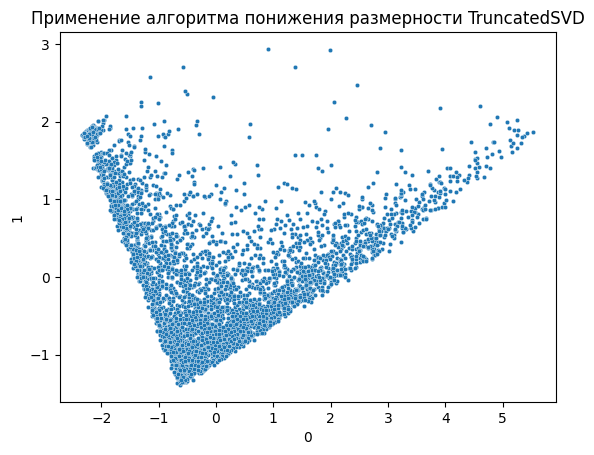

In [48]:
X_svd_df = pd.DataFrame(X_svd)
sns.scatterplot(data=X_svd_df, x=X_svd_df[0], y=X_svd_df[1], s=10)
plt.title("Применение алгоритма понижения размерности TruncatedSVD")

Как видно из графика, алгоритм TruncatedSVD не помог визуально разделить данные.
Попробуем воспользоваться другим алгоритмом - TSNE

In [49]:
# создаём объект класса TSNE
# n_components — размерность нового пространства
tsne = TSNE(n_components=2, perplexity=50, n_iter=1000, random_state=100)
# обучаем модель на данных X и применяем к матрице X уменьшение размерности
X_tsne = tsne.fit_transform(X_norm)

Визуализируем результат работы алгоритма понижения размерности TSNE.

Text(0.5, 1.0, 'Применение алгоритма понижения размерности TSNE')

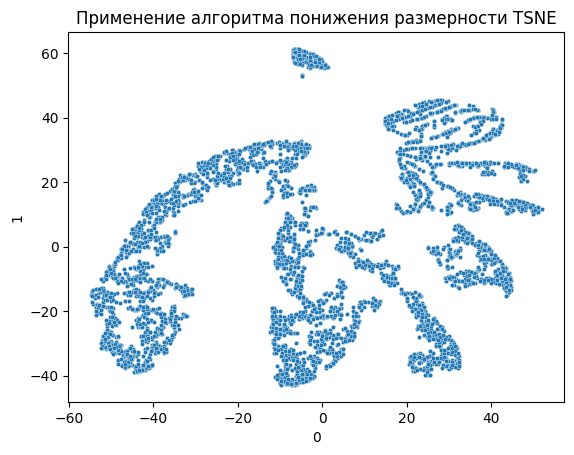

In [50]:
X_tsne_df = pd.DataFrame(X_tsne)
sns.scatterplot(data=X_tsne_df, x=X_tsne_df[0], y=X_tsne_df[1], s=10)
plt.title("Применение алгоритма понижения размерности TSNE")

Как видно из графика, данные удалось визуально дифференцировать на несколько групп.

Попробуем применить алгоритм K-means для класеризации полученных данных.
Подберем оптимальное количество кластеров для этого алгоритма клатеризации при помощи коэффициента силуэта.

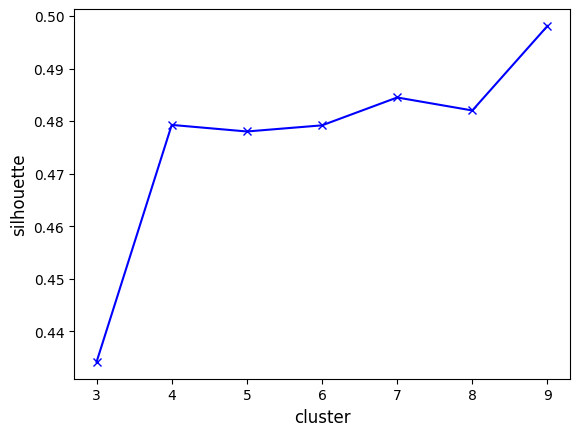

In [51]:
def get_silhouette(cluster_num, X):
    k_means =  cluster.KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_, metric='euclidean')
    return silhouette

silhouettes = []
for i in range(3, 10):
    silhouettes.append(get_silhouette(i, X_tsne))
    
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouette", fontsize=12)
plt.plot([i for i in range(3, 10)], silhouettes, 'xb-')

Согласно методу коэффициента силуета, оптимальное количество кластеров - 9.
Визуализируем разбиение данных на 9 кластеров с помощью метода кластеризации K-means.

Text(0.5, 1.0, 'Разбиение данных на 9 кластеров с помощью метода K-means')

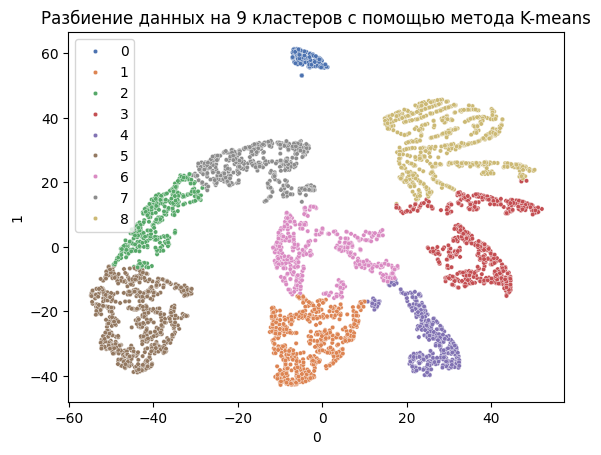

In [52]:
k_means_9 =  cluster.KMeans(n_clusters=9, random_state=42)
k_means_9.fit(X_tsne)

sns.scatterplot(data=X_tsne_df, x=X_tsne_df[0], y=X_tsne_df[1], hue = k_means_9.labels_, s=10, palette="deep")
plt.title("Разбиение данных на 9 кластеров с помощью метода K-means")

Зафиксируем полученную метрику для данного алгоритма.

In [53]:
k_means_silhouette_best = silhouette_score(X_tsne, k_means_9.labels_, metric='euclidean')
k_means_silhouette_best

0.49811003

Попробуем применить метод агломеративной кластеризации для полученного количества кластеров.

Text(0.5, 1.0, 'Разбиение данных на 9 кластеров с помощью агломеративной иерархической кластеризации')

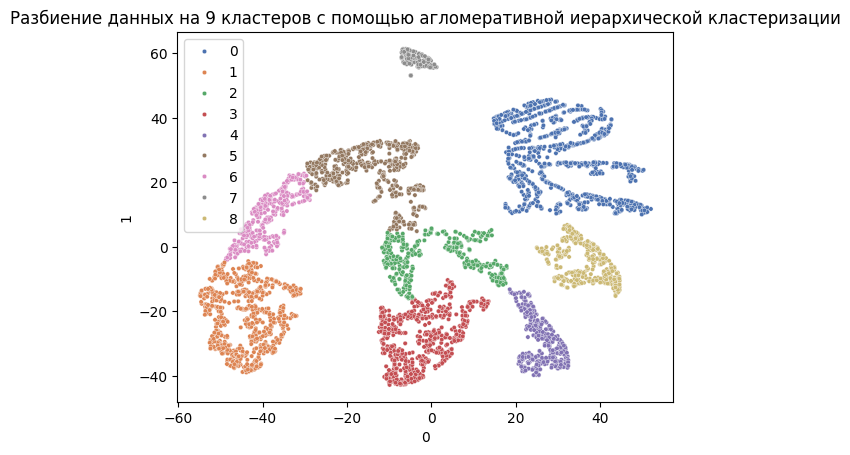

In [54]:
agg_model = cluster.AgglomerativeClustering(n_clusters=9, linkage='average')
agg_model.fit(X_tsne)

sns.scatterplot(data=X_tsne_df, x=X_tsne_df[0], y=X_tsne_df[1], hue = agg_model.labels_, s=10, palette="deep")
plt.title("Разбиение данных на 9 кластеров с помощью агломеративной иерархической кластеризации")

Зафиксируем полученную метрику для данного алгоритма.

In [55]:
agg_model_silhouette_best = silhouette_score(X_tsne, agg_model.labels_, metric='euclidean')
agg_model_silhouette_best

0.48117223

Попробуем применить алгоритм DBscan.
Для реализации алгоритма кластеризации DBscan, необходимо произвести подбор параметров кластеризации.

In [56]:
# подбираем параметры
siliuette_list_dbscan = []
 
for eps in np.arange(2.5,4,0.2):
    for min_sample in range(13,27,1):
        dbscan = cluster.DBSCAN(eps=eps, min_samples=min_sample)
        dbscan.fit(X_tsne_df)
        sil_score = silhouette_score(X_tsne_df, dbscan.labels_, metric='euclidean')
        siliuette_list_dbscan.append((eps, min_sample, sil_score, len(set(dbscan.labels_))) )
        
# выведем результаты подбора параметров как таблицу
df_dbscan = pd.DataFrame(siliuette_list_dbscan, columns=['eps', 'min_samples', 'sil_score', 'number_of_clusters'])
df_dbscan.sort_values(by = 'sil_score', ascending=False).head(5)

,eps,min_samples,sil_score,number_of_clusters
75,3.5,18,0.350542,5
59,3.3,16,0.350542,5
93,3.7,22,0.350542,5
92,3.7,21,0.350542,5
91,3.7,20,0.350542,5


Из таблицы видим, что оптимальное количество кластеров - 5, попробуем визуализировать этот результат.

In [57]:
# выполняем кластеризацию с лучшим из подобранных параметров
dbscan_best = cluster.DBSCAN(eps=3.5, min_samples=18)
dbscan_best.fit(X_tsne_df)

DBSCAN(eps=3.5, min_samples=18)

Text(0.5, 1.0, 'Разбиение данных на 5 кластеров с помощью DBscan')

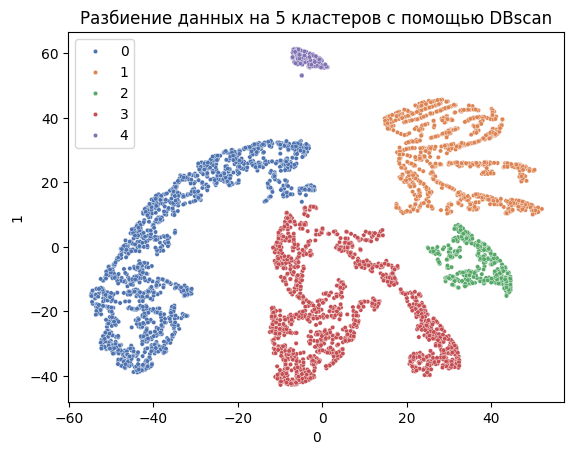

In [58]:
sns.scatterplot(data=X_tsne_df, x=X_tsne_df[0], y=X_tsne_df[1], hue = dbscan_best.labels_, s=10, palette="deep")
plt.title("Разбиение данных на 5 кластеров с помощью DBscan")

Зафиксируем полученную метрику для данного алгоритма.

In [59]:
dbscan_model_silhouette_best = silhouette_score(X_tsne, dbscan_best.labels_, metric='euclidean')
dbscan_model_silhouette_best

0.35054174

>ПРОМЕЖУТОЧНЫЙ ВЫВОД: Мы попробовали три разных алгоритма кластеризации. Согласно значению коэффициента силуэта, лучшим вариантом сегментации является первый из рассмотреных алгоритмов - K-means, с разделением данных на 9 кластеров. Однако, мне показалось, что последний алгоритм (DBscan) визуально лучше справился со своей задачей. Возьмем рзультаты его работы за основу и дольше будем ориентироваться на них.

### 3.2. Интерпретация результатов кластеризации

Перейдём к интерпретации полученных кластеров.

#### 3.2.1. Визуализация кластеров

Визуализируйте результаты в виде 3D-диаграммы с осями Recency, Frequency и Monetary. Проанализируйте полученную диаграмму и попробуйте понять, какие кластеры у вас получились.

Визуализируем на 3D графике деление на кластеры по результатам лушего алгоритма.

In [ ]:
# создадим своднюю таблицу RFM + полученное нами деление на кластеры.
rfm_labels = pd.DataFrame(dbscan_best.labels_, columns=['Clusters'], index= rfm_table_cleared.index)
rfm_clusters= pd.concat([rfm_table_cleared, rfm_labels], ignore_index=False, axis=1)
rfm_clusters

,Recency,Frequency,Monetary,Clusters
CustomerID,,,,
12346,325,1,0.00,0
12347,2,7,4310.00,1
12348,75,4,1437.24,2
12349,18,1,1457.55,3
12350,310,1,294.40,0
...,...,...,...,...
18278,73,1,173.90,0
18280,277,1,180.60,0
18281,180,1,80.82,0


Построим 3D график RFM-характеристики с кластеризацией.

In [61]:
fig = px.scatter_3d(
    data_frame=rfm_clusters, #DataFrame
    x = 'Recency', #ось абсцисс
    z = 'Frequency', #ось ординат
    y = 'Monetary', #ось аппликат
    color='Clusters', #расцветка в зависимости от страны
    opacity=0.7,
    width=1000,
    height=700,
    title='RFM-характеристики с кластеризацией'
)

#отображаем график
fig.show()

На графике выше видно разделение данных на кластеры, однако их все равно сложно интерпретировать.

#### 3.2.2. Построение профиля кластеров

Далее составьте так называемый профиль кластеров. Для этого вам необходимо вернуться от декомпозированных данных (если вы производили понижение размерности) к RFM-таблице (очищенной от выбросов).

Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков.

Чтобы результаты было проще интерпретировать, давайте познакомимся с одним из способов визуализации профиля кластеров — **Radar Chart** (полярная диаграмма, или диаграмма паутины). Это графическое представление значений нескольких эквивалентных категорий в форме паутины.

Radar Chart часто используется при определении профиля кластеров. На концах паутины откладываются оси, соответствующие признакам, описывающим объекты. На каждой из осей для каждого кластера откладываются средние значения соответствующих характеристик. Соединив точки по осям, мы получаем многоугольник. 

Пример полярной диаграммы для задачи кластеризации учеников по интересам:

<img src=https://www.datanovia.com/en/wp-content/uploads/2020/12/radar-chart-in-r-customized-fmstb-radar-chart-1.png width=500>

На этой диаграмме мы видим визуализацию признаков для одного из кластеров. Видно, что ученики, принадлежащие этому кластеру, в большей степени увлекаются музыкой (Music), а в меньшей — программированием (Programm).

В модуле `graph_objects` библиотеки `plotly` есть встроенная функция `Scatterpolar`, которая позволяет построить полярную диаграмму. На основе этой функции мы подготовили для вас функцию `plot_cluster_profile()`, которая позволяет визуализировать профиль каждого из кластеров в виде полярной диаграммы. У неё есть два параметра: `grouped_data` — сгруппированные по кластерам характеристики объектов (клиентов), `n_clusters` — количество кластеров.

Главное условие использования полярной диаграммы — все признаки должны быть приведены к единому масштабу с помощью нормализации, где 1 будет означать максимум, а 0 — минимум. Шаг с нормализацией мы также добавили в функцию `plot_cluster_profile()`.


In [62]:
def plot_cluster_profile(grouped_data, n_clusters):
    """Функция для визуализации профиля кластеров в виде полярной диаграммы.

    Args:
        grouped_data (DataFrame): таблица, сгруппированная по номерам кластеров с агрегированными характеристиками объектов.
        n_clusters (int): количество кластеров
    """
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаём список признаков
    features = grouped_data.columns
    # Создаём пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаём полярную диаграмму и добавляем её на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название — номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show()

In [63]:
grouped_data = rfm_clusters.groupby('Clusters').agg({'Recency': 'mean',
                                            'Frequency': 'mean',
                                            'Monetary': 'mean'})
grouped_data

,Recency,Frequency,Monetary
Clusters,,,
0,144.828797,1.028653,320.963782
1,32.633444,6.803987,2419.715437
2,41.327160,4.040123,1089.385833
3,82.272379,2.420811,713.939556
4,365.456140,1.043860,235.531930


Теперь у вас есть удобный инструмент для анализа профиля кластеров. Воспользуйтесь им, чтобы проинтерпретировать результаты, полученные на предыдущем шаге.

In [64]:
plot_cluster_profile(grouped_data, n_clusters=5)

ВЫВОДЫ по графику: данный инструмент визуализации RFM-пространства дает более наглядную картину сегментации нашего датасета. например, хорошо разделены 1 и 4 кластры. То есть клиенты с небольшим количеством заказов, сделанными уже достаточно давно и клиенты с большим по общему количеству и частоте заказов(а также по количеству потраченных денег). Остальные группы клиентов также довольно хорощшо дифференцируются.

#### Построение предскательной модели на основе полученных классов клиентов.

Попробуем построить простую модель логистической регрессии на основе полученных значений кластеров для наших данных. Другими словами, проверим, как этот алгоритм предскажет полученную сегментацию. Для этого разделим данные на тестовую и тренировочную части.

In [65]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_norm, dbscan_best.labels_, 
    test_size=0.3,
    stratify = dbscan_best.labels_,
    random_state=42
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# смотрим соотношение классов в тренировочной и тестовой выборках
print(np.bincount(y_train)/y_train.shape[0]*100)
print(np.bincount(y_test)/y_test.shape[0]*100)

(2830, 3) (1214, 3) (2830,) (1214,)
[34.5229682  22.33215548  8.02120141 32.29681979  2.82685512]
[34.51400329 22.32289951  7.99011532 32.3723229   2.80065898]


In [66]:
# обучаем модель на тренировочной части данных
lin_reg = linear_model.LogisticRegression()
lin_reg.fit(X_train, y_train)
# предсказываем классы на тестовой части данных
y_test_pred = lin_reg.predict(X_test)

# выводим метрики на тестовой части данных
print("Precision Score : ", precision_score(y_test, y_test_pred, average=None))
print("Recall Score : ", recall_score(y_test, y_test_pred, average=None))
print("F-1 Score : ", f1_score(y_test, y_test_pred, average=None))

Precision Score :  [0.98313253 0.92057762 0.8        0.92682927 0.91891892]
Recall Score :  [0.97374702 0.94095941 0.6185567  0.96692112 1.        ]
F-1 Score :  [0.97841727 0.93065693 0.69767442 0.94645081 0.95774648]


> ПРОМЕЖУТОЧНЫЙ ВЫВОД: Несмотря на построение довольно простой предсказательной модели с параметрами по умолчаниию, получили неплохие значения метрик на тестовой части данных. Подобная модель могла бы делать предсказания лояльности покупателя на основе записей о сделанных им заказов в магазине.

## 5. Выводы и оформление работы

Напишите заключение о проделанной работе и полученных результатах. Отметьте, какие сегменты клиентов вам удалось найти в данных.

После завершения проекта создайте в своём репозитории файл README.md и кратко опишите содержимое проекта по принципу, который мы приводили ранее.

Выложите свой проект на GitHub и оформите удалённый репозиторий, добавив в него описание и теги репозитория (теги придумайте самостоятельно в зависимости от того, какую задачу вы решали).

>ОБЩИЕ ВЫВОДЫ: 
1. Произведен базовый анализ структуры исходных данных, найдены основные статистические характеристики признаков, сделаны первичные выводы о структуре данных и их особенностях.
2. Выполнены необходимые преобразования данных и их очистка.
3. Произведен разведывательный анализ данных и визуализацию данных.
4. Построена RFM таблица, в которой найдены и удалены данные с выбросами.
5. С помощью алгоритмов понижения размерности данных удалось получить визуализировать разделение пользователей магазина на группы.
6. С помощью алгоритмов кластеризации и критериев ее оценки, произведена сегментация клиентов магазина путем выбора лучшего алгоритмов из опробованных.
7. Выполнена визуализация результатов работы каждого из использованных алгоритмов кластеризации и дана их оценка.
8. Построены профили кластеров визуализированы в виде диаграммы, по которой сделаны выводы.
9. дополнительно построена предскательная модель логистической регрессии (обучение с учителем) при помощи полученных в процессе кластеризации меток классов, произведена оценка данной модели.
10. Проект выложен в репозитарий GitHub.